# Higher Order Derivatives

A guided notebook on the **second derivative** and **higher order derivatives**.

This notebook explains:
- what the second derivative is
- the different notations: $f''(x)$ and $\dfrac{d^2y}{dx^2}$
- the physical meaning of the second derivative (acceleration)
- third, fourth, and $n$-th order derivatives

This notebook follows the same style template as the uploaded guidelines.

## 1. Introduction

You already know how to find the derivative of a function. You also know that the derivative of a function is **itself a function**.

So we can take the derivative of a derivative!

If we differentiate $f(x)$ once we get $f'(x)$. If we differentiate again, we get

$$
\big(f'(x)\big)' = f''(x)
$$

This is the **second derivative** of $f(x)$: the derivative of the derivative.

After completing this notebook you will be able to:
- compute second and higher order derivatives,
- read and use the standard notations,
- interpret the second derivative as a *rate of change of a rate of change* (e.g. acceleration).

## 2. Notation

If we have a function $y = f(x)$, the first derivative is denoted by

$$
\frac{dy}{dx}.
$$

Taking the derivative of that gives the second derivative:

$$
\frac{d}{dx}\left(\frac{dy}{dx}\right) = \frac{d^2 y}{dx^2}.
$$

We can also write the second derivative as $f''(x)$.

| Order | Prime notation | Leibniz notation |
|-------|----------------|------------------|
| 1st   | $f'(x)$        | $\dfrac{dy}{dx}$ |
| 2nd   | $f''(x)$       | $\dfrac{d^2y}{dx^2}$ |
| 3rd   | $f'''(x)$      | $\dfrac{d^3y}{dx^3}$ |
| $n$-th| $f^{(n)}(x)$   | $\dfrac{d^ny}{dx^n}$ |

Writing four primes is tedious, so from the fourth derivative on we usually write $f^{(4)}(x)$, and in general the $n$-th derivative is $f^{(n)}(x)$.

## 3. Worked Example: A Polynomial

Consider

$$
f(x) = 6x^3 + 2x + 8.
$$

**First derivative:**

$$
f'(x) = 18x^2 + 2.
$$

**Second derivative** (differentiate again):

$$
f''(x) = 36x.
$$

Notice how each differentiation lowers the degree of the polynomial by one.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

### Symbolic check with SymPy

We can confirm the result symbolically. The `diff` function takes an optional argument for the order of the derivative.

In [2]:
x = sp.symbols('x')
f = 6*x**3 + 2*x + 8

first  = sp.diff(f, x)        # f'(x)
second = sp.diff(f, x, 2)     # f''(x)  (order 2)

print('f(x)   =', f)
print("f'(x)  =", first)
print("f''(x) =", second)

f(x)   = 6*x**3 + 2*x + 8
f'(x)  = 18*x**2 + 2
f''(x) = 36*x


## 4. Physical Meaning of the Second Derivative

The first derivative represents the **rate of change** of a function.

Therefore the second derivative represents the **rate of change of the rate of change**.

This idea is central to **kinematics** — the study of motion. Imagine the graph of an object's position versus time:

$$
\text{position} \;\xrightarrow{\;\frac{d}{dt}\;}\; \text{velocity} \;\xrightarrow{\;\frac{d}{dt}\;}\; \text{acceleration}
$$

- The derivative of **position** with respect to time is **velocity**.
- The derivative of **velocity** with respect to time is **acceleration**.

So **acceleration is the second derivative of position**.

| Quantity     | Relation        | Units      |
|--------------|-----------------|------------|
| Position $s$ | $s(t)$          | m          |
| Velocity $v$ | $s'(t)$         | m/s        |
| Acceleration $a$ | $s''(t)$    | m/s²       |

## 5. Worked Example: Acceleration

Suppose the position of an object is

$$
s(t) = t^4 + 5t - 7.
$$

**What is the acceleration after 8 seconds?**

We need the second derivative, then plug in $t = 8$.

**Velocity:**

$$
s'(t) = 4t^3 + 5.
$$

**Acceleration:**

$$
s''(t) = 12t^2.
$$

At $t = 8$:

$$
s''(8) = 12 \cdot 8^2 = 12 \cdot 64 = 768 \ \text{m/s}^2.
$$

In [3]:
t = sp.symbols('t')
s = t**4 + 5*t - 7

velocity     = sp.diff(s, t)        # s'(t)
acceleration = sp.diff(s, t, 2)     # s''(t)

print('position     s(t)  =', s)
print("velocity     s'(t) =", velocity)
print("acceleration s''(t)=", acceleration)
print('acceleration at t = 8:', acceleration.subs(t, 8), 'm/s^2')

position     s(t)  = t**4 + 5*t - 7
velocity     s'(t) = 4*t**3 + 5
acceleration s''(t)= 12*t**2
acceleration at t = 8: 768 m/s^2


## 6. Visualizing Position, Velocity, and Acceleration

Let us plot $s(t)$, $s'(t)$, and $s''(t)$ together so we can see how each curve is the slope of the one before it.

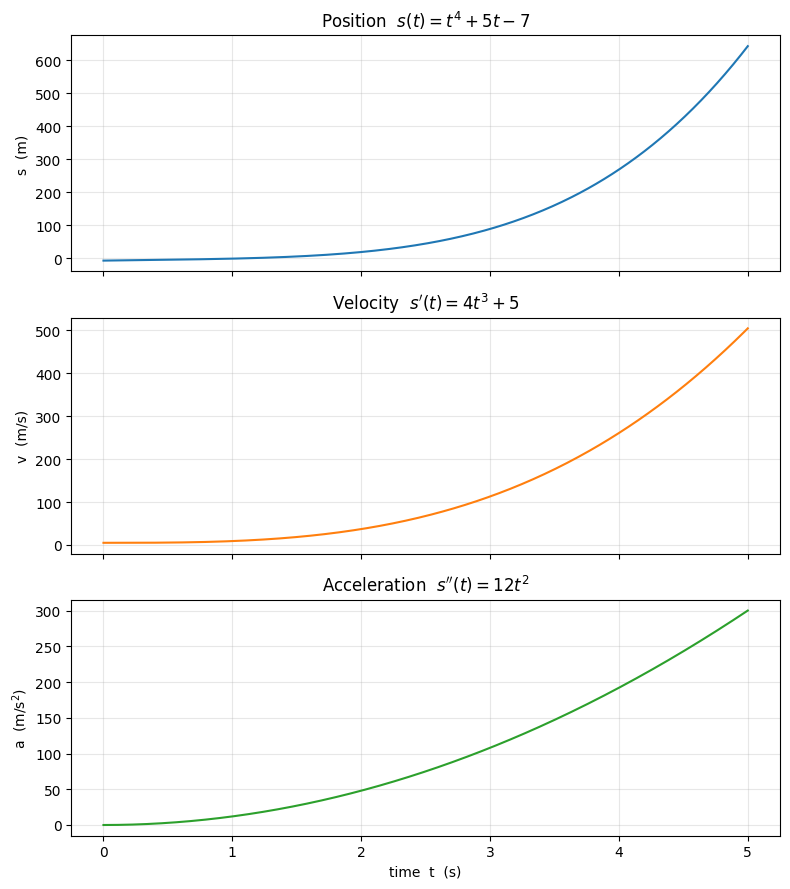

In [4]:
t_vals = np.linspace(0, 5, 400)

position     = t_vals**4 + 5*t_vals - 7
velocity     = 4*t_vals**3 + 5
acceleration = 12*t_vals**2

fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

axes[0].plot(t_vals, position, color='tab:blue')
axes[0].set_title(r"Position  $s(t) = t^4 + 5t - 7$")
axes[0].set_ylabel('s  (m)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_vals, velocity, color='tab:orange')
axes[1].set_title(r"Velocity  $s'(t) = 4t^3 + 5$")
axes[1].set_ylabel('v  (m/s)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_vals, acceleration, color='tab:green')
axes[2].set_title(r"Acceleration  $s''(t) = 12t^2$")
axes[2].set_ylabel('a  (m/s$^2$)')
axes[2].set_xlabel('time  t  (s)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. The Second Derivative and Concavity

Beyond motion, the sign of the second derivative tells us about the **shape** of a curve:

- If $f''(x) > 0$, the curve is **concave up** (bends upward, like a cup $\smile$).
- If $f''(x) < 0$, the curve is **concave down** (bends downward, like a cap $\frown$).
- A point where $f''(x)$ changes sign is an **inflection point**.

Consider $f(x) = x^3$. Then

$$
f'(x) = 3x^2, \qquad f''(x) = 6x.
$$

Here $f''(x) = 6x$ is negative for $x < 0$ and positive for $x > 0$, so $x = 0$ is an inflection point.

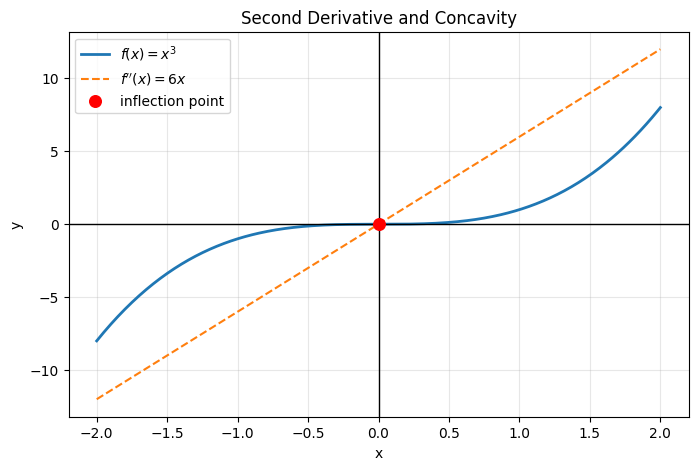

In [5]:
x_vals = np.linspace(-2, 2, 400)
y      = x_vals**3
y2     = 6*x_vals          # second derivative

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y,  label=r"$f(x) = x^3$", linewidth=2)
plt.plot(x_vals, y2, label=r"$f''(x) = 6x$", linestyle='--')
plt.scatter([0], [0], s=70, color='red', zorder=5, label='inflection point')
plt.title('Second Derivative and Concavity')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, lw=1, color='black')
plt.axvline(0, lw=1, color='black')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 8. Higher Order Derivatives

Just as we took a second derivative, we can keep going: a third derivative, a fourth, and so on.

- The **third derivative** of $y = f(x)$ is the derivative of the second derivative, denoted $f'''(x)$ or $\dfrac{d^3 y}{dx^3}$.
- For the **fourth derivative** we write $f^{(4)}(x)$ instead of four primes.
- In general, the **$n$-th derivative** is $f^{(n)}(x)$, obtained by differentiating $f$ a total of $n$ times.

### Example

Let $f(x) = x^5$. Differentiating repeatedly:

$$
\begin{aligned}
f'(x)    &= 5x^4 \\
f''(x)   &= 20x^3 \\
f'''(x)  &= 60x^2 \\
f^{(4)}(x) &= 120x \\
f^{(5)}(x) &= 120 \\
f^{(6)}(x) &= 0
\end{aligned}
$$

After the fifth derivative the function becomes a constant, and every derivative beyond that is zero.

In [6]:
x = sp.symbols('x')
f = x**5

current = f
for n in range(1, 7):
    current = sp.diff(current, x)
    print(f"f^({n})(x) = {current}")

f^(1)(x) = 5*x**4
f^(2)(x) = 20*x**3
f^(3)(x) = 60*x**2
f^(4)(x) = 120*x
f^(5)(x) = 120
f^(6)(x) = 0


## 9. Exercises

### Basic

1. Find $f''(x)$ for $f(x) = 4x^3 - 7x^2 + x$.
2. Find the second derivative of $f(x) = x^4$.

### Intermediate

3. An object moves with position $s(t) = 2t^3 - t^2 + 4$. Find its acceleration at $t = 3$.
4. Find $f'''(x)$ for $f(x) = x^4 + 2x^3$.

### Advanced

5. For $f(x) = x^6$, find the smallest $n$ such that $f^{(n)}(x)$ is a non-zero constant, and give that constant.
6. Explain, in terms of concavity, what the sign of $f''(x)$ tells you about the graph of $f$.

## 10. Solutions / Checks

**1.** $f(x) = 4x^3 - 7x^2 + x$

$$
f'(x) = 12x^2 - 14x + 1, \qquad f''(x) = 24x - 14.
$$

**2.** $f(x) = x^4$

$$
f'(x) = 4x^3, \qquad f''(x) = 12x^2.
$$

**3.** $s(t) = 2t^3 - t^2 + 4$

$$
s'(t) = 6t^2 - 2t, \qquad s''(t) = 12t - 2.
$$

At $t = 3$: $\ s''(3) = 12\cdot 3 - 2 = 34 \ \text{m/s}^2$.

**4.** $f(x) = x^4 + 2x^3$

$$
f'(x) = 4x^3 + 6x^2,\quad f''(x) = 12x^2 + 12x,\quad f'''(x) = 24x + 12.
$$

**5.** For $f(x) = x^6$, the sixth derivative is the first constant: $f^{(6)}(x) = 720$. So $n = 6$ and the constant is $720$ (which is $6!$).

**6.** If $f''(x) > 0$ the graph is concave up (bends upward); if $f''(x) < 0$ it is concave down (bends downward). A sign change of $f''$ marks an inflection point.

Run the cell below to verify the symbolic answers.

In [7]:
x, t = sp.symbols('x t')

print('1.', sp.diff(4*x**3 - 7*x**2 + x, x, 2))
print('2.', sp.diff(x**4, x, 2))

accel = sp.diff(2*t**3 - t**2 + 4, t, 2)
print('3.', accel, '-> at t=3:', accel.subs(t, 3))

print('4.', sp.diff(x**4 + 2*x**3, x, 3))
print('5.', sp.diff(x**6, x, 6))

1. 2*(12*x - 7)
2. 12*x**2
3. 2*(6*t - 1) -> at t=3: 34
4. 12*(2*x + 1)
5. 720


## 11. Conclusion

In this notebook we explored **higher order derivatives**.

- The **second derivative** $f''(x)$ is the derivative of the derivative.
- It can be written as $f''(x)$ or $\dfrac{d^2 y}{dx^2}$.
- An **$n$-th derivative** $f^{(n)}(x)$ is found by differentiating a function $n$ times.
- The second derivative is the rate of change of the rate of change. In kinematics this is **acceleration**, the second derivative of position.
- The sign of the second derivative also describes **concavity** and locates **inflection points**.

Key lesson:

$$
\text{position} \;\xrightarrow{\;\frac{d}{dt}\;}\; \text{velocity} \;\xrightarrow{\;\frac{d}{dt}\;}\; \text{acceleration}.
$$